# **Sales Performance Analysis**

### Internship Project

# Import Libraries

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)

# Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Load Dataset

In [35]:
df = pd.read_csv("Sales_Performance_Analysis.csv", encoding="latin1")

In [36]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


# Understanding Dataset

In [37]:
print("Rows and Columns:", df.shape)

Rows and Columns: (9800, 18)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [39]:
df.describe(include="all")

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,5/9/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


# Data Cleaning

### Check Missing Values

In [40]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


### Handle Missing Values

In [41]:
df["Postal_Code"] = df["Postal_Code"].fillna(df["Postal_Code"].median())

### Check Duplicate Records

In [42]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Convert Data Columns

In [43]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)

df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)

In [72]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Year', 'Month', 'Month_Num', 'Quarter', 'Day',
       'Shipping_Days'],
      dtype='object')

# **Feature Engineering**


### Create Time Features

In [73]:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month_name()
df["Month_Num"] = df["Order_Date"].dt.month
df["Quarter"] = df["Order_Date"].dt.quarter
df["Day"] = df["Order_Date"].dt.day

### Calculate Shipping Time

In [74]:
df["Shipping_Days"] = (
    df["Ship_Date"] - df["Order_Date"]
).dt.days

In [75]:
df[["Order_Date","Ship_Date","Shipping_Days"]].head()

,Order_Date,Ship_Date,Shipping_Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9800 non-null   int64         
 1   Order_ID       9800 non-null   object        
 2   Order_Date     9800 non-null   datetime64[ns]
 3   Ship_Date      9800 non-null   datetime64[ns]
 4   Ship_Mode      9800 non-null   object        
 5   Customer_ID    9800 non-null   object        
 6   Customer_Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal_Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product_ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub_Category   9800 n

# **Exploratory Data Analysis**

In [77]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row_ID,9800.0,4900.5,1.0,2450.75,4900.5,7350.25,9800.0,2829.160653
Order_Date,9800,2017-05-01 05:13:51.673469440,2015-01-03 00:00:00,2016-05-24 00:00:00,2017-06-26 00:00:00,2018-05-15 00:00:00,2018-12-30 00:00:00,NaN
Ship_Date,9800,2017-05-05 04:17:52.653061120,2015-01-07 00:00:00,2016-05-27 18:00:00,2017-06-29 00:00:00,2018-05-19 00:00:00,2019-01-05 00:00:00,NaN
Postal_Code,9800.0,55276.498571,1040.0,23223.0,58103.0,90008.0,99301.0,32023.374393
Sales,9800.0,230.769059,0.444,17.248,54.49,210.605,22638.48,626.651875
Year,9800.0,2016.724184,2015.0,2016.0,2017.0,2018.0,2018.0,1.123984
Month_Num,9800.0,7.818469,1.0,5.0,9.0,11.0,12.0,3.281905
Quarter,9800.0,2.885816,1.0,2.0,3.0,4.0,4.0,1.057449
Day,9800.0,15.486837,1.0,8.0,16.0,23.0,31.0,8.753733
Shipping_Days,9800.0,3.961122,0.0,3.0,4.0,5.0,7.0,1.749614


### Sales Distribution

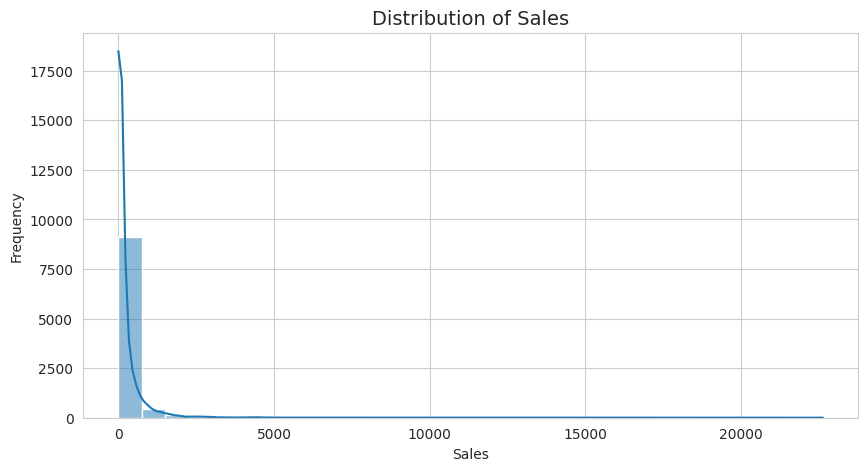

In [78]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="Sales",
    bins=30,
    kde=True
)

plt.title("Distribution of Sales", fontsize=14)
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Detect Sales Outliers

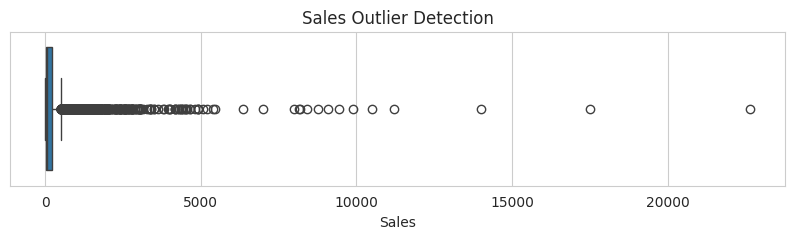

In [79]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Sales"]
)

plt.title("Sales Outlier Detection")

plt.show()

# **KPI Analysis**

### Total Revenue

In [80]:
total_sales = df["Sales"].sum()

print(f"Total Revenue : ${total_sales:,.2f}")

Total Revenue : $2,261,536.78


### Number Of Orders

In [81]:
total_orders = df["Order_ID"].nunique()

print(f"Total Orders : {total_orders}")

Total Orders : 4922


### Average Order Value

In [82]:
average_order_value = (
    df.groupby("Order_ID")["Sales"]
      .sum()
      .mean()
)

print(f"Average Order Value : ${average_order_value:,.2f}")

Average Order Value : $459.48


### Average Shipping Time

In [83]:
avg_shipping = df["Shipping_Days"].mean()

print(f"Average Shipping Time : {avg_shipping:.2f} Days")

Average Shipping Time : 3.96 Days


### Unique Customers

In [84]:
customers = df["Customer_ID"].nunique()

print(f"Unique Customers : {customers}")

Unique Customers : 793


### Revenue per Customer

In [85]:
revenue_customer = total_sales / customers

print(f"Revenue per Customer : ${revenue_customer:,.2f}")

Revenue per Customer : $2,851.87


In [86]:
kpi = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Average Shipping Time",
        "Unique Customers",
        "Revenue per Customer"
    ],
    "Value":[
        f"${total_sales:,.2f}",
        total_orders,
        f"${average_order_value:,.2f}",
        f"{avg_shipping:.2f} Days",
        customers,
        f"${revenue_customer:,.2f}"
    ]
})

kpi

,Metric,Value
0,Total Revenue,"$2,261,536.78"
1,Total Orders,4922
2,Average Order Value,$459.48
3,Average Shipping Time,3.96 Days
4,Unique Customers,793
5,Revenue per Customer,"$2,851.87"


# **Business Analysis & Visualizations**

### Monthly Sales Trend

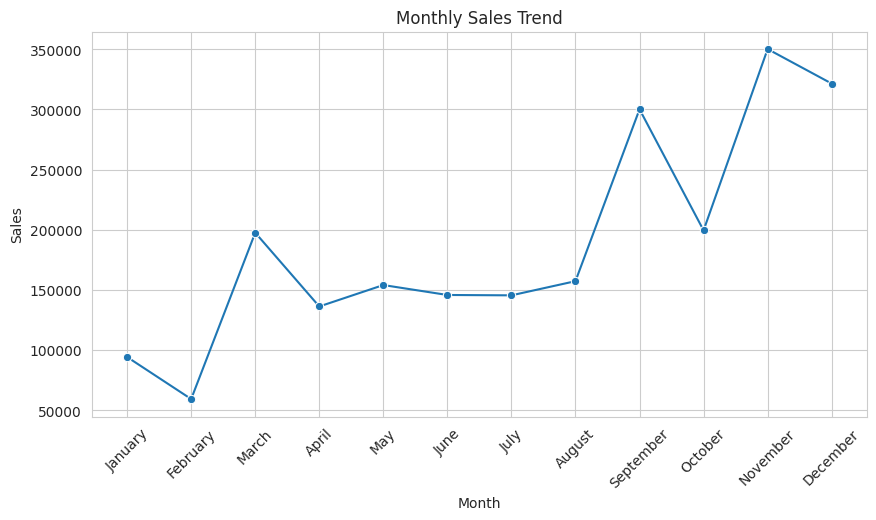

In [66]:
monthly_sales = df.groupby(["Month_Num", "Month"], as_index=False)["Sales"].sum()
monthly_sales = monthly_sales.sort_values("Month_Num")

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="Month", y="Sales", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

### Sales by Region

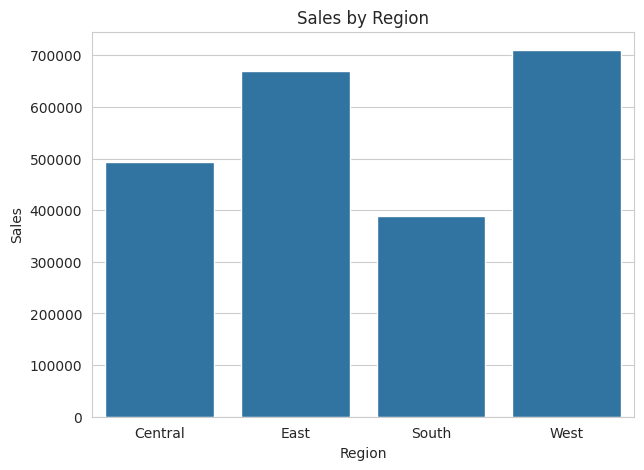

In [87]:
region_sales = df.groupby("Region", as_index=False)["Sales"].sum()

plt.figure(figsize=(7,5))
sns.barplot(data=region_sales, x="Region", y="Sales")

plt.title("Sales by Region")
plt.show()

### Sales by Category

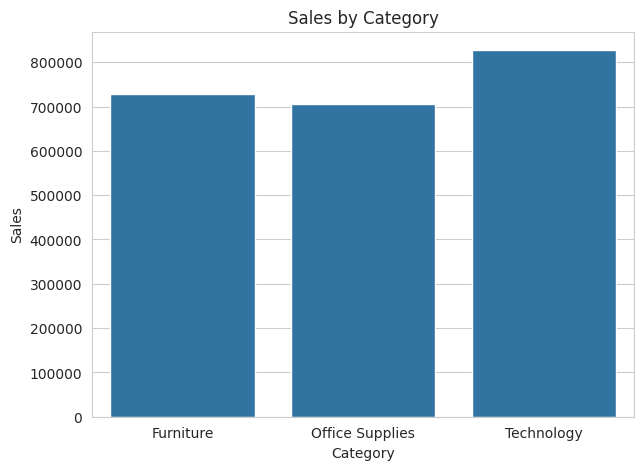

In [68]:
category_sales = df.groupby("Category", as_index=False)["Sales"].sum()

plt.figure(figsize=(7,5))
sns.barplot(data=category_sales, x="Category", y="Sales")

plt.title("Sales by Category")
plt.show()

### Top 10 Products

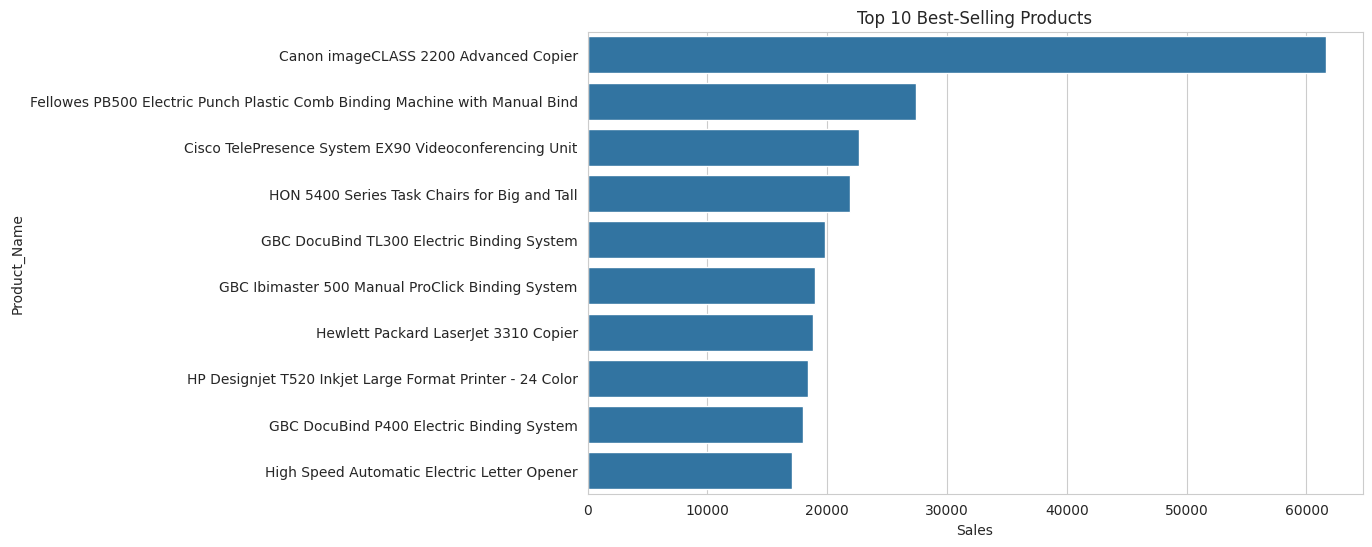

In [69]:
top_products = (
    df.groupby("Product_Name", as_index=False)["Sales"]
      .sum()
      .nlargest(10, "Sales")
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_products, x="Sales", y="Product_Name")

plt.title("Top 10 Best-Selling Products")
plt.show()

### Bottom 10 Products

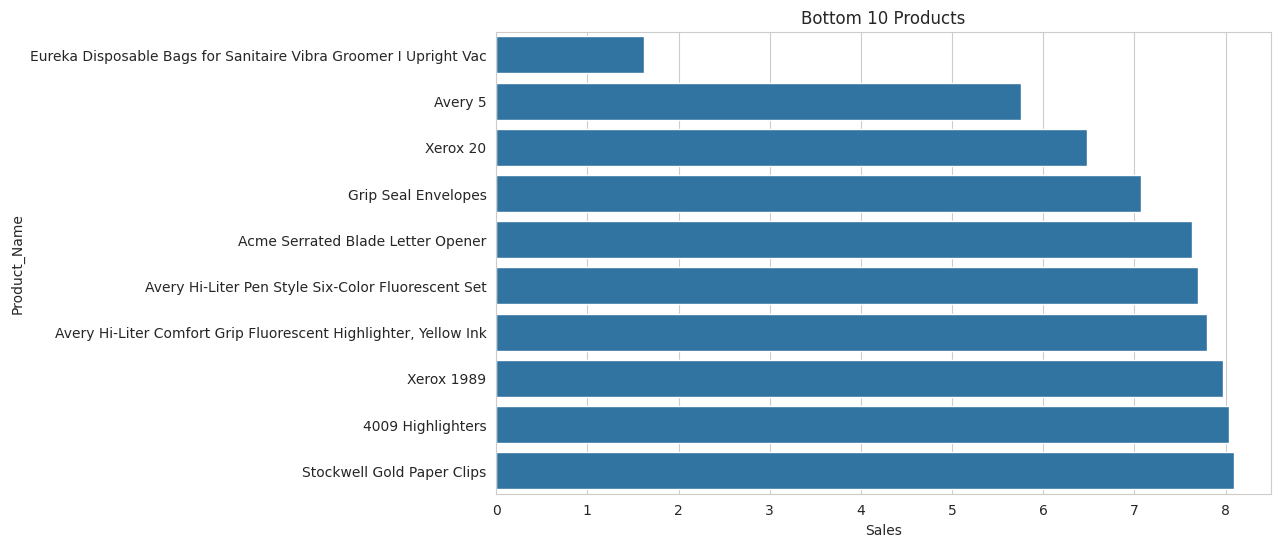

In [70]:
bottom_products = (
    df.groupby("Product_Name", as_index=False)["Sales"]
      .sum()
      .nsmallest(10, "Sales")
)

plt.figure(figsize=(10,6))
sns.barplot(data=bottom_products, x="Sales", y="Product_Name")

plt.title("Bottom 10 Products")
plt.show()

### Sales by Segment

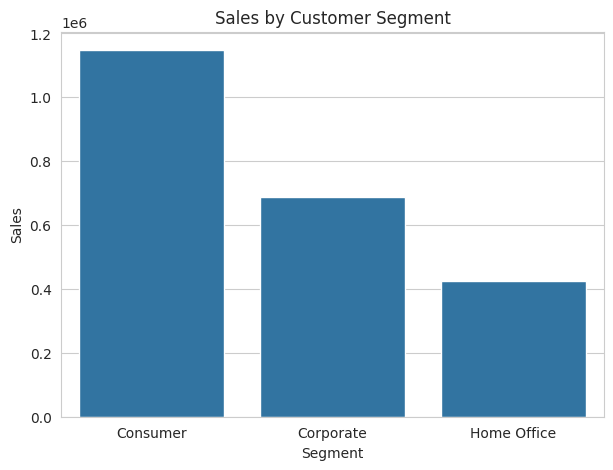

In [71]:
segment_sales = df.groupby("Segment", as_index=False)["Sales"].sum()

plt.figure(figsize=(7,5))
sns.barplot(data=segment_sales, x="Segment", y="Sales")

plt.title("Sales by Customer Segment")
plt.show()